# Daily Bike Rentals — KNN Regression (Clean Dataset)
This notebook trains a **K-Nearest Neighbors (KNN)** regression model on the cleaned dataset.

Features used: `season`, `mnth`, `weathersit`, `temp`, `hum`, `windspeed`.
The `yr` column is removed to prevent data leakage.
KNN predicts rentals based on the most similar past days.

## 1) Imports & Setup

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ⚙️ Path to your dataset
DATA_PATH = r"C:\Users\koran\Desktop\Semester 3 AI Machine Learning and Data\Individual Challenges\First Individual Challenge\DAIA\data\processed\bike_daily_clean.csv"


## 2) Load and Inspect Data

In [75]:
df = pd.read_csv(DATA_PATH)

if "dteday" in df.columns:
    df["dteday"] = pd.to_datetime(df["dteday"], errors="coerce")

if "yr" in df.columns:
    df.drop(columns="yr", inplace=True)

print("✅ Data Loaded Successfully")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head(5))


✅ Data Loaded Successfully
Shape: (731, 20)
Columns: ['temp', 'hum', 'windspeed', 'cnt', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12']


,temp,hum,windspeed,cnt,season_2,season_3,season_4,weathersit_2,weathersit_3,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12
0,0.344167,0.805833,0.160446,985,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,0.363478,0.696087,0.248539,801,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,0.196364,0.437273,0.248309,1349,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.200000,0.590435,0.160296,1562,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.226957,0.436957,0.186900,1600,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 3) Prepare Features and Train/Test Split (80/20)

In [76]:
y = df["cnt"].values
X = df.drop(columns=["cnt", "dteday"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Feature columns:", list(X.columns))


Train shape: (584, 19) | Test shape: (147, 19)
Feature columns: ['temp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12']


## 4) Build and Tune KNN Model

In [77]:
categorical, numeric = [], []
for c in X_train.columns:
    if X_train[c].dtype.kind in "bifc":
        numeric.append(c)
    else:
        categorical.append(c)

for c in ["season", "mnth", "weathersit"]:
    if c in X_train.columns:
        if c in numeric: numeric.remove(c)
        if c not in categorical: categorical.append(c)

numeric = [c for c in numeric if c not in categorical]

prep = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

knn = KNeighborsRegressor()

pipe = Pipeline([
    ("prep", prep),
    ("model", knn)
])

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 30],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

print("⏳ Running GridSearchCV...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("✅ Best Parameters:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 3))


⏳ Running GridSearchCV...


✅ Best Parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
Best CV R²: 0.523


## 5) Evaluate on Test Set

In [78]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 KNN Regression — Test Results")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")



📊 KNN Regression — Test Results
RMSE: 1307.817 | MAE: 1151.403 | R²: 0.573


## 6) Residual Plot

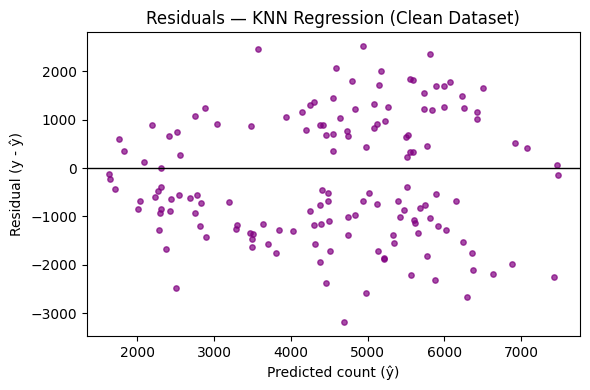

In [79]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, s=15, alpha=0.7, color='purple')
plt.axhline(0, color='black', lw=1)
plt.xlabel("Predicted count (ŷ)")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals — KNN Regression (Clean Dataset)")
plt.tight_layout()
plt.show()
